In [1]:
#Setup and Imports
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
#Abstract Problem Interface

class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [3]:
#Node Class
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1

@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)
    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [4]:
#Helper Functions
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions
def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }
def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [5]:
#Implemenenting the grid search problem

MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
        return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        legal_actions = []
        # 2. For each action in MOVES:
        #       a. Compute the neighbour cell.
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions.
        row,col = state

          #Checking UP
        new_row= row-1
        new_col=col
        new_state = (new_row,new_col)
        if self.in_bounds(new_state) and self.is_free(new_state):
            legal_actions.append("UP")

          #Checking DOWN
        new_row= row+1
        new_col=col
        new_state = (new_row,new_col)
        if self.in_bounds(new_state) and self.is_free(new_state):
            legal_actions.append("DOWN")

          #Checking LEFT
        new_row= row
        new_col=col-1
        new_state = (new_row,new_col)
        if self.in_bounds(new_state) and self.is_free(new_state):
            legal_actions.append("LEFT")

          #Checking RIGHT
        new_row= row
        new_col=col+1
        new_state = (new_row,new_col)
        if self.in_bounds(new_state) and self.is_free(new_state):
            legal_actions.append("RIGHT")


        # 3. Return legal_actions.
        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        row,col = state

        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)
        if action == "UP":
          return (row-1,col)
        elif action == "DOWN":
          return (row + 1,col)
        elif action == "LEFT":
          return (row,col-1)
        elif action == "RIGHT":
          return (row,col+1)
        else:
          raise ValueError(f"Unknown action: {action}")

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        return 1.0



In [6]:
#Self-Check For Grid Problem
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [7]:
#Sample Drone Map
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [8]:
#Visualisation Helper
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()




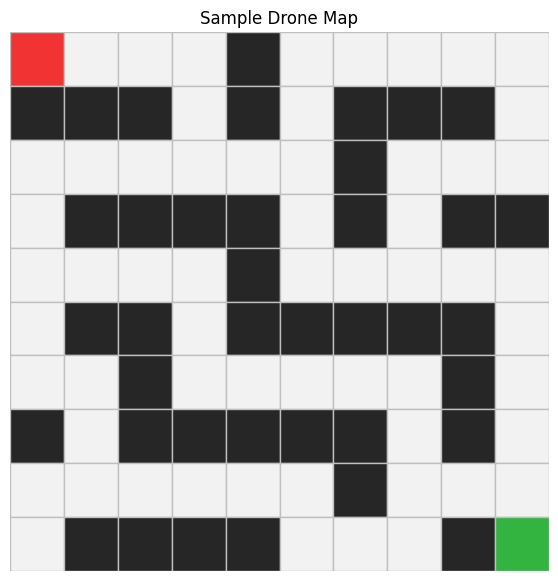

In [9]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [10]:
#Shared expand Method
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        #--I'm finding the current position in the problem the state
        #--Store it in s

        # s <- node.STATE
        s = node.state
        # for each action in problem.ACTIONS(s):
        # s_prime <- problem.RESULT(s, action)

        for action in problem.actions(s):
              s_prime = problem.result(s,action)

         #cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)

              cost = node.path_cost + problem.action_cost(s,action,s_prime)

        # yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
              yield Node(state = s_prime,parent = node, action = action ,path_cost =cost)


    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [11]:
from collections import  deque
#Breadth-First Search
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        # TODO 6:
        # Implement BFS graph search using a FIFO queue.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        node = Node(problem.initial_state())
        # 2. If the initial state is the goal, return success.
        if problem.is_goal(node.state):
          return SearchResult(
              algorithm="BFS",
              status="success",
              solution=node,
              nodes_expanded=0,
              max_frontier_size=1,
              reached_count=1
              )
        # 3. Create a deque frontier and add the initial node.
        frontier = deque([node])
        # 4. Create a reached set and add the initial state.
        reached = {problem.initial_state()}
        # 5. While frontier is not empty:
        #       a. pop from the LEFT of the deque.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. for each child:
        #            i. if child is goal, return success.
        #           ii. if child.state is not in reached:
        #                  add child.state to reached.
        #                  append child to frontier.
        #       e. update max_frontier_size.
        # 6. Return failure if no solution is found.
        #
         # Hint:
        # frontier = deque([node])
        # node = frontier.popleft()
        nodes_expanded = 0
        max_frontier_size=1

        while frontier:
          node = frontier.popleft()
          nodes_expanded += 1
          for child in self.expand(problem, node):
            s = child.state
            if problem.is_goal(s):
              return SearchResult(
                  algorithm="BFS",
                  status="success",
                  solution=child,
                  nodes_expanded=nodes_expanded,
                  max_frontier_size=max_frontier_size,
                  reached_count=len(reached)
                )

            if s not in reached:
                reached.add(s)
                frontier.append(child)

            max_frontier_size = max(max_frontier_size,len(frontier))
          return  SearchResult(
                algorithm="BFS",
                status="failure",
                solution=None,
                nodes_expanded=nodes_expanded,
                max_frontier_size=max_frontier_size,
                reached_count=len(reached)
                )


In [12]:
#Depth-First Search

#Study the algorithm then follow the To-Do Tasks


class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        # TODO 7:
        # Implement DFS graph search using a stack.
        #
        # Steps:
        # 1. Create the initial node.
        node = Node(problem.initial_state())


        # 2. If the initial state is the goal, return success.
        if problem.is_goal(node.state):
          return SearchResult(
              algorithm="DFS",
              status="success",
              solution=node,
              nodes_expanded=0,
              max_frontier_size=1,
              reached_count=1
              )
        # 3. Use a Python list as the stack frontier.
        frontier = [node]

        # 4. Use a reached set.
        reached = {problem.initial_state()}

        # 5. While frontier is not empty:
        #       a. pop from the end of the list.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. add unreached children to the stack.
        #       e. update max_frontier_size.
        #
        # Note:
         # If you want DFS to explore actions in the same order as MOVES,
        # you may need to reverse the children before pushing them.
        nodes_expanded = 0
        max_frontier_size=1


        while frontier:
          node = frontier.pop()
          nodes_expanded += 1

          #Reversing children to maintain the same order as MOVESS
          children = list(self.expand(problem,node))
          for child in reversed(children):
            s = child.state
            if problem.is_goal(s):
              return SearchResult(
                  algorithm="DFS",
                  status="success",
                  solution=child,
                  nodes_expanded=nodes_expanded,
                  max_frontier_size=max_frontier_size,
                  reached_count=len(reached)
                )

            if s not in reached:
                reached.add(s)
                frontier.append(child)

            max_frontier_size = max(max_frontier_size,len(frontier))
            return  SearchResult(
                algorithm="DFS",
                status="failure",
                solution=None,
                nodes_expanded=nodes_expanded,
                max_frontier_size=max_frontier_size,
                reached_count=len(reached)
                )


In [13]:
#Depth Limited Search
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
      ) -> Tuple[Optional[Node], str]:
        # TODO 8:
        # Implement recursive depth-limited search.
        #
        # Steps:
        # 1. If node.state is goal, return (node, "success").
        if problem.is_goal(node.state):
          return (node ,"sucess")
        # 2. Else if node.depth >= limit, return (None, "cutoff").

        elif node.depth>= limit:
          return (None,"cutoff")
        else:
          metrics["nodes_expanded"] += 1

          cutoff_occured = False

          for child in self.expand(problem, node):
            if state_is_on_path(node,child.state) :
              continue

            new_stack_size = current_stack_size + 1
            if new_stack_size > metrics["max_stack_size"]:
              metrics["max_stack_size"] = new_stack_size

            result,status = self._recursive_dls(
                problem = problem,
                node=child,
                limit=limit,
                metrics=metrics,
                current_stack_size=new_stack_size
            )

            if status == "success":
              return(result, "success")

            elif status == "cutoff":
              cutoff_occured=True
          if cutoff_occured:
            return(None,"cutoff")
          else:
            return(None,"failure")

        # 3. Otherwise:
        #       a. increment metrics["nodes_expanded"].
        #       b. set cutoff_occurred = False.
        #       c. for each child in expand(problem, node):
        #             i. skip the child if child.state already appears on the current path.
        #            ii. update max_stack_size.
        #           iii. recursively call _recursive_dls on the child.
        #            iv. if result is "success", return success immediately.
        #             v. if result is "cutoff", set cutoff_occurred = True.
        #       d. after all children:
        #             if cutoff_occurred, return (None, "cutoff")
        #             else return (None, "failure")



In [14]:
#Iterative Deepening Search
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # TODO 9:
        #Creating a DLS object
        dls = DepthLimitedSearch()

        # Implement IDS by repeatedly running DLS from limit 0 to max_depth.
        #

        # Requirements:
        # 1. Keep a list called iteration_log.
        iteration_log =[]

        #Tracking accumulated metrics
        total_nodes_expanded = 0
        max_stack_size_overall = 0
        # 2. Accumulate total nodes expanded across all DLS iterations.
        # 3. Track the maximum stack size seen in any DLS run.
        #Limit from 0 to max_depth
        for limit in range(0,max_depth + 1):
          #Calling DLS with current limit
          result = dls.search(problem, limit=limit)
          #Recording the limit and status in the iteration log
          iteration_log.append({
              "limit":limit,
              "status":result.status,
              "nodes_expanded":result.nodes_expanded,
              "max_stack_size":result.max_frontier_size

          })
           #Accumulating metrics
          total_nodes_expanded += result.nodes_expanded
          max_stack_size_overall=max(max_stack_size_overall,result.max_frontier_size)
        # 4. If a DLS run returns success, return a SearchResult for IDS.
          if result.status == "success" :
            return SearchResult(
              algorithm=algorithm,
              status="success",
              solution=result.solution,
              nodes_expanded=total_nodes_expanded,
              max_frontier_size=max_stack_size_overall,
              reached_count=0,
              limit=result.limit,
              iterations=iteration_log
              )
        # 5. If a DLS run returns failure, IDS can stop early and return failure.
          elif result.status == "failure":
            return SearchResult(
              algorithm=algorithm,
              status="failure",
              solution=None,
              nodes_expanded=total_nodes_expanded,
              max_frontier_size=max_stack_size_overall,
              reached_count=0,
              limit=result.limit,
              iterations=iteration_log
              )
        # 6. If all limits return cutoff up to max_depth, return cutoff.
        #
        # Hint:
        # dls = DepthLimitedSearch()
        # result = dls.search(problem, limit=limit)
        return SearchResult(
              algorithm=algorithm,
              status="cutoff",
              solution=None,
              nodes_expanded=total_nodes_expanded,
              max_frontier_size=max_stack_size_overall,
              reached_count=0,
              limit=max_depth,
              iterations=iteration_log
              )


In [15]:
#Running the algorithms on the sample map
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,failure,NaN,None,None,1,1,2
1,DFS,failure,NaN,None,None,1,1,2
2,DLS,cutoff,10.0,None,None,16,11,0
3,IDS,cutoff,30.0,None,None,1523,31,0


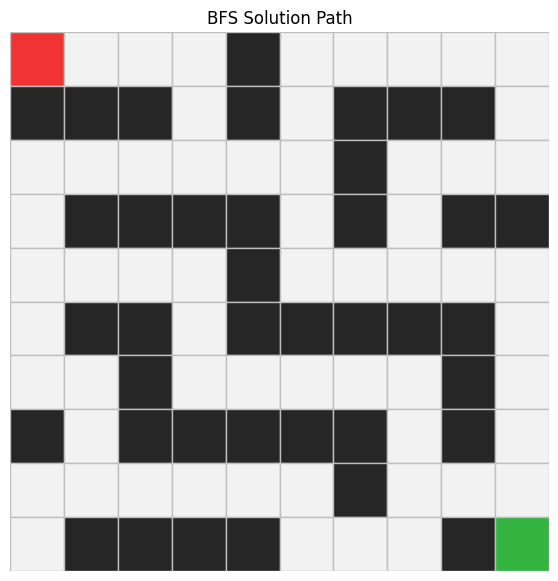

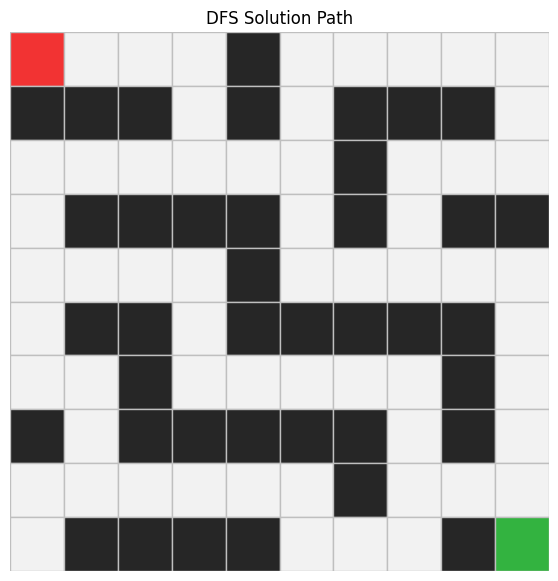

In [16]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

In [17]:
#Creating my own map 1
#A map with a long narrow corridor
#For a long narrow corridor only the top and bottom rows are free
#A 15 x 15 matrix
custom_grid_1 =[
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]

]

custom_start_1 = None
custom_goal_1 = None

#Example after completing:
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
 ]
show_results(custom_results_1)


,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,0.0,0.0,0,1,1
1,DFS,success,NaN,0.0,0.0,0,1,1
2,DLS,sucess,20.0,0.0,0.0,0,1,0
3,IDS,cutoff,40.0,NaN,NaN,0,1,0


In [18]:
#Creating my own map 2
#A larger map, 20 × 20 with many dead ends

custom_grid_2 =[
    [0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0],
    [0,1,1,1,1,1,0,0,1,0,1,1,0,0,0,0,1,1,0,0],
    [0,1,0,1,0,0,0,1,1,1,0,0,1,1,0,0,1,0,1,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,1,0,0,0,0,1,1,1,1,1,0,0,0,0,1,0,0,0,1],
    [0,0,1,1,1,1,1,0,0,0,1,0,0,1,1,1,1,1,1,0],
    [0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0],
    [1,1,1,0,0,0,0,1,1,1,1,0,0,0,1,1,0,0,1,1],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,1,1,1,1,1,1,1,0,0,1,0,0,1,1,0,1,0,0,0],
    [0,1,0,1,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0],
    [0,0,0,1,1,1,0,0,0,0,1,0,0,1,1,0,1,1,1,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [1,1,1,1,1,1,1,1,0,0,1,0,0,1,1,0,1,1,0,0],
    [0,1,0,0,0,1,1,1,0,0,1,0,0,1,0,1,1,1,0,0],
    [0,1,0,1,0,0,1,0,0,0,1,1,1,0,1,0,1,0,0,0],
    [1,0,1,0,1,0,0,1,0,0,1,1,1,1,1,0,0,0,0,0],
    [0,1,1,1,1,1,0,0,0,0,1,0,1,1,1,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0],
    [0,1,1,1,1,1,1,1,1,1,0,0,0,1,1,1,1,0,1,0]


]
custom_start_2 = None
custom_goal_2 = None
# Example after completing:
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
     bfs.search(custom_problem_2),
     dfs.search(custom_problem_2),
     dls.search(custom_problem_2, limit=20),
    ids.search(custom_problem_2, max_depth=40),
]
show_results(custom_results_2)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,0.0,0.0,0,1,1
1,DFS,success,NaN,0.0,0.0,0,1,1
2,DLS,sucess,20.0,0.0,0.0,0,1,0
3,IDS,cutoff,40.0,NaN,NaN,0,1,0


#Reflection Questions

#15.1 Problem Foundation
1.A state is the current position of the agent in the grid represented as a tuple(row,column).Example: (0,0) can be said to be a state.

2.An action is what the agent(drone) does in the grid,whether it moves up,down,left or right.They are legal moves available from a state.

3.The result function gives the outcome after an action is performed. Let's say when the robot is in cell (0,0) and it moves to the right and enters cell (0,1) . It will now be in cell(0,1) and that will be the result.

4.Separating the problem definition from the search algorithm makes the code reusable. The same search algorithm can be applied to different problems, and different search algorithms can be tested on the same problem without changing the problem definition.


#15.2 BFS
1.BFS uses a FIFO queue so that the first node discovered is the first node expanded. This allows BFS to explore all nodes at one depth before moving to the next depth.

2.BFS finds the shortest path because it searches through all nodes horizontally . It expands the node in order of increading depth.

3.The reached set contains all the nodes that have been discovered.It helps BFS rememeber states it has already explored so that it doesn't visit it again

#15.3 DFS
In DFS ,the nodes are expanded vertically .That is, for every node, it will be expanded in a vertical manner till it reaches a point and if the node isn't found,it goes to the top and expands the associated horizontal node. It uses a stack because it imitates the last in first out approach ,allowing it to explore the deepest node first.

2.No ,it isn't guaranteed to find the shortest path.It expands the deepest node on the frontier first so it will take a long time to find the shortest path.


3.DFS can use less memory than BFS becuase unlike BFS that stores all nodes at the current depth level,DFS stores only the current path and a number of neighbouring nodes.

4.DFS can perform badly in infinitie state spaces or spaces with cycles.

#15.4  DLS

1.When the depth limit is too small,the algorithm may not find the solution if the solution is deeper than the limit because it stops when it reaches the limit.

2.Cutoff occurs when the algorithm has reached the depth-limit but the solution hasn't been found. The algorithm stops searching and reports that the search was cutoff.

3.DLS is a version of DFS where there is a fixed limit  on how deep the search will go. DFS explores as deep as possible without restriction while the DLS stops exploring once it has reached the depth limit.

4.Path-cycle checking is used in DLS to avoid revisiting nodes that are already  in the current search path,it doesn't store all reached states which prevents cycles and infinite loops. This makes its memory efficient and avoids redundant exploration.

#15.5 IDS
1.IDS repeats DLS with increasing limits to make sure the solution is found if it exists starting from the shallowest level and gradually going deeper until the solution is found.

2.IDS is complete because it keeps increasing the depth limit,ensuring that it will reach the depth of the solution if the solution exists while DLS with a small limit is incomplete because it stops searching when its limit is reached and doesn't continue deeper even if the solution hasn't been found.

3.IDS uses less memory than BFS becauses it uses DFS-like memory usage where it doesn't store a memory of all the nodes at a given level but rather only the current path.

4.The cost of IDS repeatedly searching from the root is redundant exploration because nodes near the top of the tree are explored many times at each depth limit

#15.6 Real-World Drone Context
1.A route with a good weather condition , without any physical obstacle like buidings or trees and accurate positioning information(such as reliable GPS data) to ensure correct navigation.

2.I would choose the BFS because at each level,it expands all successor nodes at that level before moving to the next level.This ensures that the first solution found uses the fewest number of moves given that all steps have equal cost.

3.I would choose DLS if I want to limit how deep the drone is allowed to search. This is because ,DLS restricts the search to a fixed depth limit and if the solution is beyond that limit, it wouldn't be explored. This can help control how far the drone will perform its search.

4.The grid model is a simplified representation and doesn't capture real-world complexities. For instance; in the grid ,the movement is restricted because there are fixed cells but for a real drone navigation ,they move in continuous space. In the real drone navigation there is a presence of dynamic obstacles but in the grid ,the obstacles are fixed. Basically, grid models do not reflect real-world uncertainties.